In [1]:
%config InlineBackend.figure_format = 'retina'

In [2]:
import joblib
import pandas as pd

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import RandomizedSearchCV, KFold
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline

from xgboost import XGBRegressor

from scipy.stats import randint, uniform

import cv2
from skimage.feature import hog, local_binary_pattern


import matplotlib.gridspec as gridspec
import shap
import matplotlib as mpl

In [3]:
model_dt = joblib.load("best_model_dt.joblib")
model_rf = joblib.load("rf_best_model.joblib")
model_xgb = joblib.load("xgb_best_model.joblib")

model_dt_cl = joblib.load("best_model_dt_cl.joblib")
model_rf_cl = joblib.load("rf_best_model_cl.joblib")
model_xgb_cl = joblib.load("xgb_best_model_cl.joblib")

In [4]:
train1 = pd.read_csv("data_divided/training_full.csv")
val = pd.read_csv("data_divided/validation_full.csv")
train = pd.concat([train1, val], ignore_index = True)

test = pd.read_csv("data_divided/test_full.csv")

train1_cl = pd.read_csv("data_divided/training_cleaned.csv")
val_cl = pd.read_csv("data_divided/validation_cleaned.csv")
train_cl = pd.concat([train1_cl, val_cl], ignore_index = True)

test_cl = pd.read_csv("data_divided/test_cleaned.csv")


print(f"The shape of train set: {train.shape}")
print(f"The shape of test set: {test.shape}")

print(f"The shape of train set, clean: {train_cl.shape}")
print(f"The shape of test set, clean: {test_cl.shape}")

The shape of train set: (16724, 12)
The shape of test set: (4181, 12)
The shape of train set, clean: (15323, 12)
The shape of test set, clean: (3809, 12)


In [5]:
# remowe image_path for models on tabular data

train_tab = train.drop(columns = "image_path")
test_tab = test.drop(columns = "image_path")

train_tab_cl = train_cl.drop(columns = "image_path")
test_tab_cl = test_cl.drop(columns = "image_path")

In [6]:
X_train, y_train = train_tab[train_tab.drop(columns = "price_numeric").columns.to_list()], train_tab["price_numeric"]
X_test, y_test = test_tab[test_tab.drop(columns = "price_numeric").columns.to_list()], test_tab["price_numeric"]

X_train_cl, y_train_cl = train_tab_cl[train_tab_cl.drop(columns = "price_numeric").columns.to_list()], train_tab_cl["price_numeric"]
X_test_cl, y_test_cl = test_tab_cl[test_tab_cl.drop(columns = "price_numeric").columns.to_list()], test_tab_cl["price_numeric"]

In [7]:
import shap
import numpy as np
import pandas as pd

def compute_shap_beeswarm(
    best_model,
    X_train,
    X_test,
    background_size=200,
    random_state=42,
):
    # reproducibility
    np.random.seed(random_state)

    # --- extract pipeline parts ---
    preprocessor = best_model.named_steps["preprocessing"]
    model = best_model.named_steps["model"]

    # --- transform data ---
    X_train_trans = preprocessor.transform(X_train)
    X_test_trans = preprocessor.transform(X_test)

    # --- feature names ---
    feature_names = preprocessor.get_feature_names_out()

    # --- convert to DataFrame ---
    X_test_df = pd.DataFrame(X_test_trans, columns=feature_names)

    # --- background sample ---
    rng = np.random.default_rng(random_state)
    n_background = min(background_size, X_train_trans.shape[0])
    idx = rng.choice(X_train_trans.shape[0], size=n_background, replace=False)

    X_background = pd.DataFrame(X_train_trans[idx], columns=feature_names)

    # --- SHAP ---
    explainer = shap.Explainer(model, X_background)
    shap_values = explainer(X_test_df, check_additivity=False)

    return shap_values, X_test_df, feature_names

In [8]:
# --- ORIGINAL DATA ---
shap_dt,  X_dt,  features = compute_shap_beeswarm(model_dt,  X_train, X_test)
shap_rf,  X_rf,  _        = compute_shap_beeswarm(model_rf,  X_train, X_test)
shap_xgb, X_xgb, _        = compute_shap_beeswarm(model_xgb, X_train, X_test)

# --- CLEANED DATA ---
shap_dt_cl,  X_dt_cl,  features_cl = compute_shap_beeswarm(model_dt_cl,  X_train_cl, X_test_cl)
shap_rf_cl,  X_rf_cl,  _           = compute_shap_beeswarm(model_rf_cl,  X_train_cl, X_test_cl)
shap_xgb_cl, X_xgb_cl, _           = compute_shap_beeswarm(model_xgb_cl, X_train_cl, X_test_cl)

100%|===================| 3796/3809 [02:17<00:00]        

In [9]:
shap_original = {
    "Decision Tree": shap_dt,
    "Random Forest": shap_rf,
    "XGBoost": shap_xgb
}

shap_cleaned = {
    "Decision Tree": shap_dt_cl,
    "Random Forest": shap_rf_cl,
    "XGBoost": shap_xgb_cl
}

In [10]:
import pandas as pd
import numpy as np

def shap_to_df(shap_values, feature_names):
    return pd.DataFrame(shap_values.values, columns=feature_names)

def compute_importance(shap_df, top_k=12):
    return shap_df.abs().mean().sort_values(ascending=False).head(top_k)


# --- build storage ---
data = {
    "Decision Tree": shap_dt,
    "Random Forest": shap_rf,
    "XGBoost": shap_xgb
}

results = {}

for name, shap_vals in data.items():
    shap_df = shap_to_df(shap_vals, features)
    importance = compute_importance(shap_df)

    results[name] = {
        "shap_values": shap_vals,
        "shap_df": shap_df,
        "importance": importance
    }

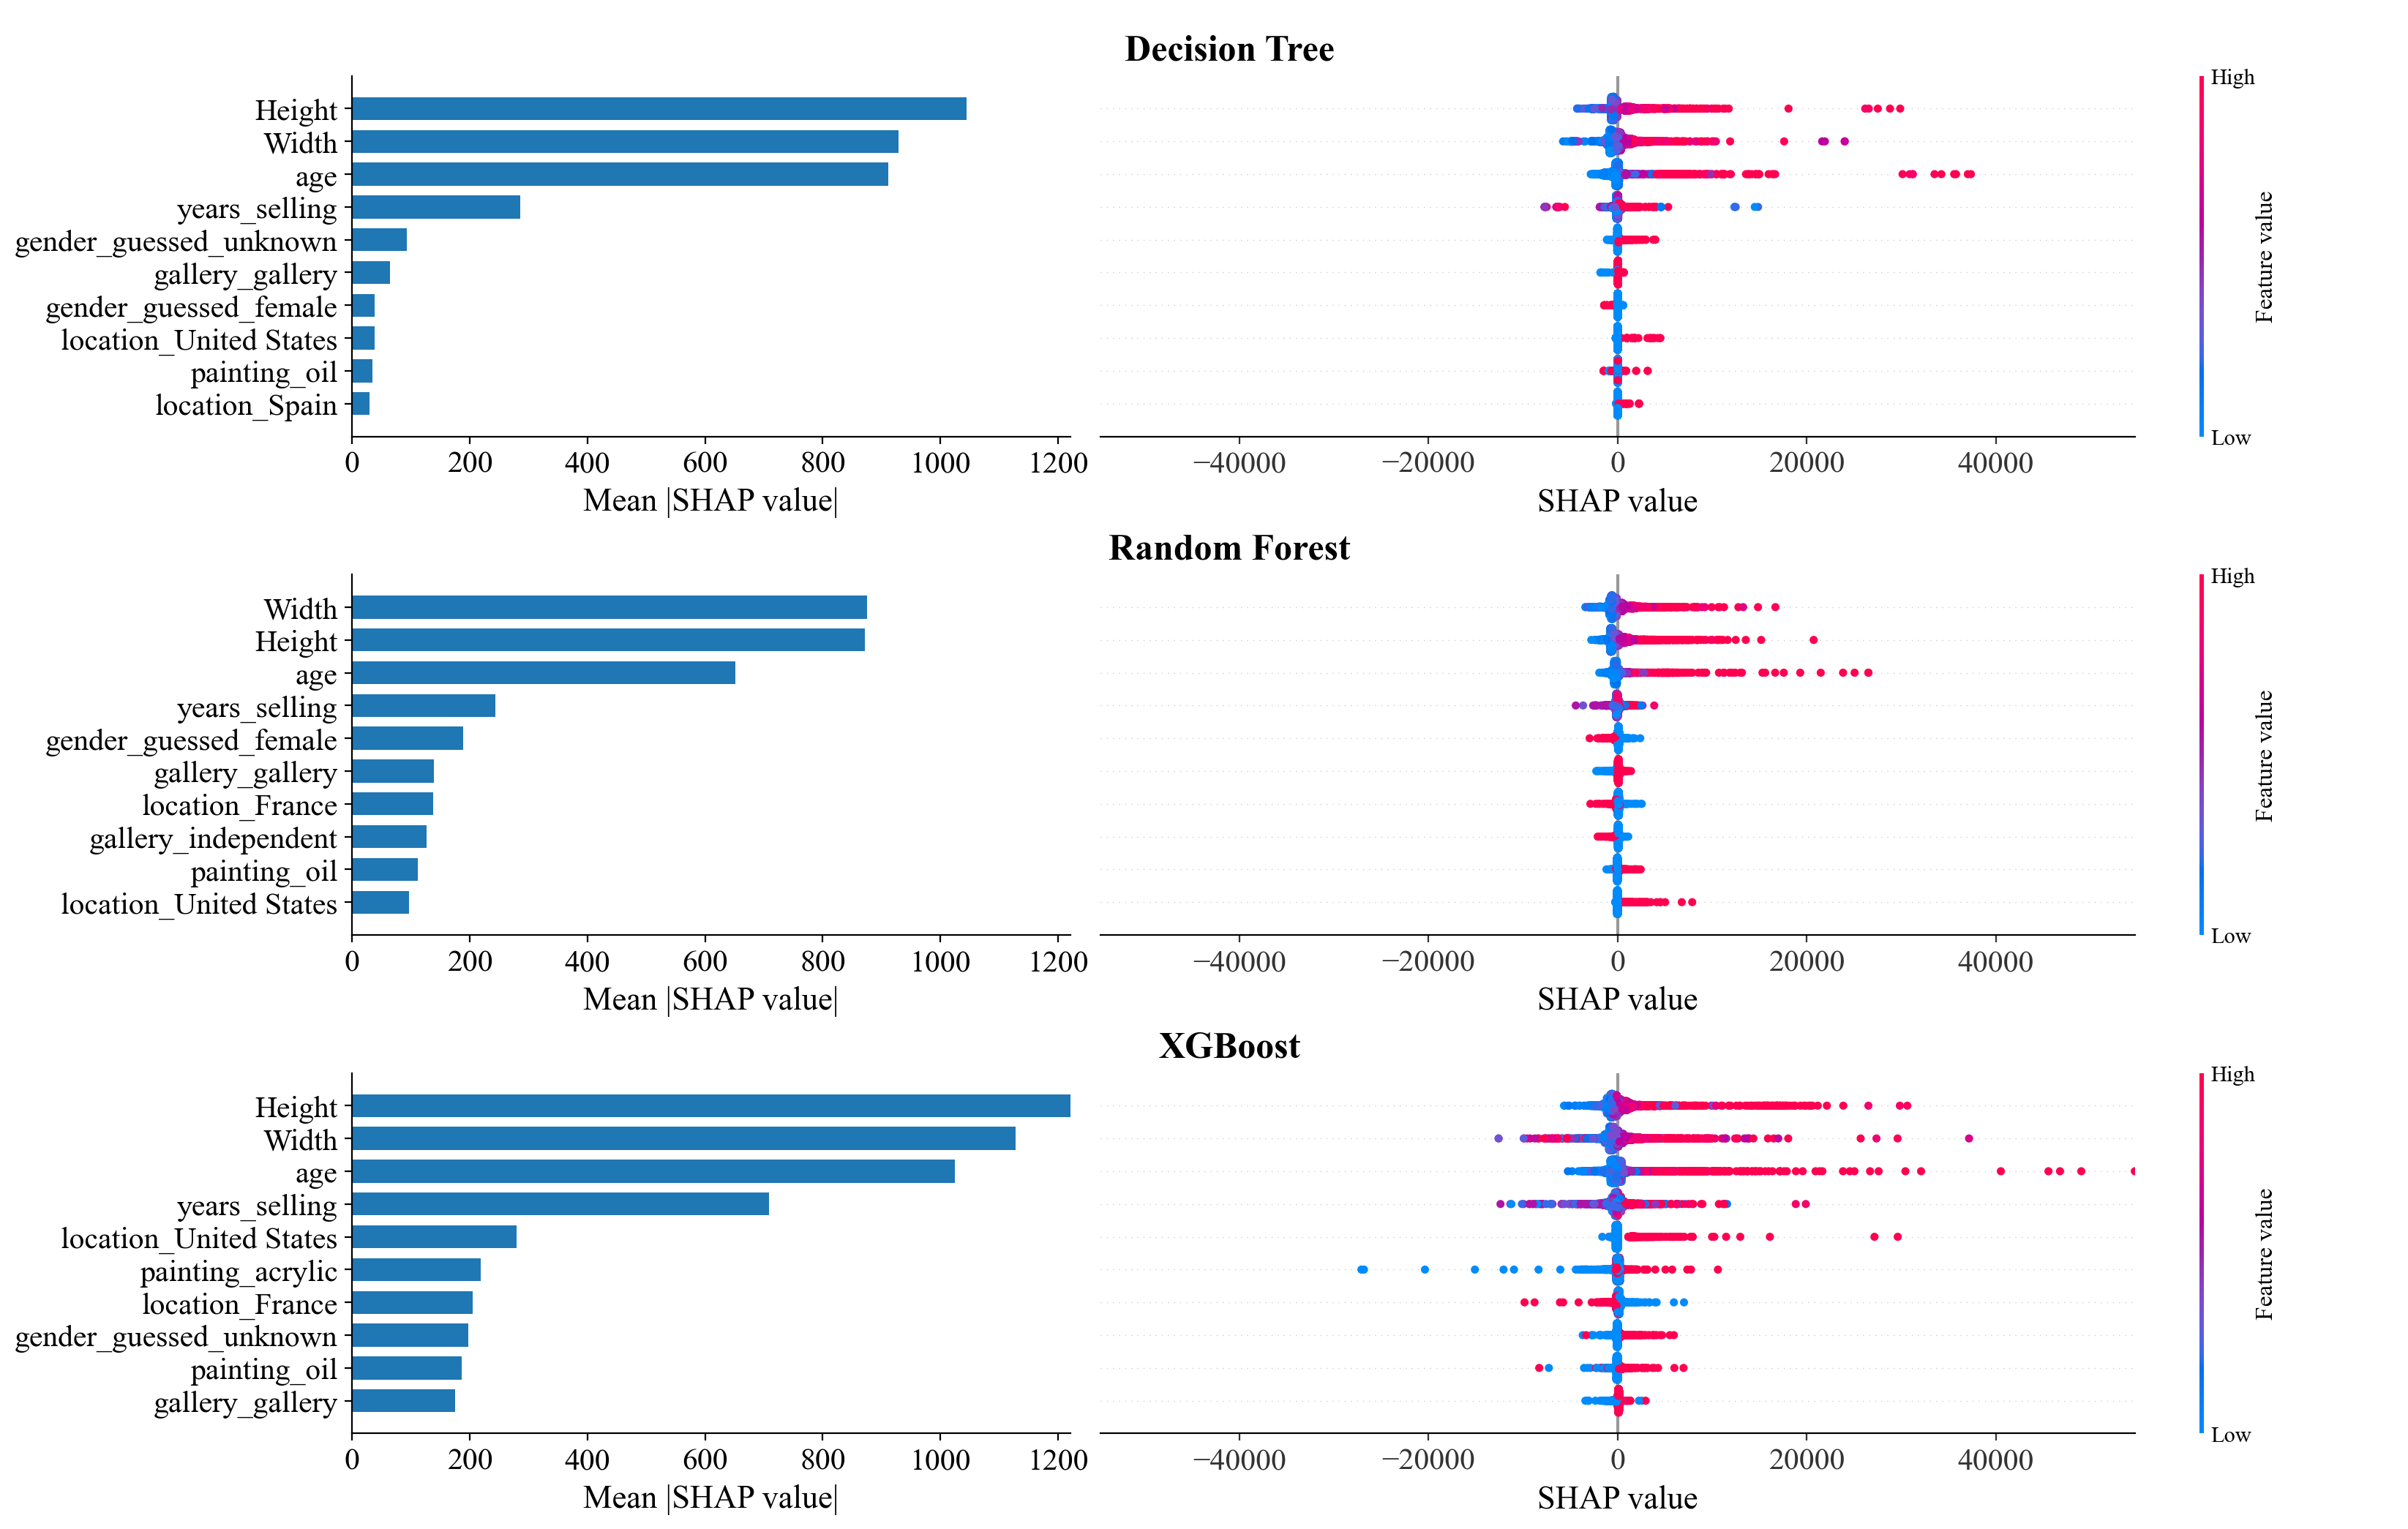

In [11]:

mpl.rcParams["font.family"] = "serif"
mpl.rcParams["font.serif"] = ["Times New Roman"]

TOP_K = 10


TITLE_SIZE = 18
LABEL_SIZE = 16
TICK_SIZE = 15


all_shap_max = []
all_importance_max = []

for res in results.values():
    imp = res["importance"].head(TOP_K)
    shap_vals = res["shap_values"][:, imp.index.tolist()]

    all_importance_max.append(imp.values.max())
    all_shap_max.append(np.abs(shap_vals.values).max())

xmax_importance = max(all_importance_max)
xmax_shap = max(all_shap_max)


n_models = len(results)

fig = plt.figure(figsize=(18, 4.2 * n_models))

outer = gridspec.GridSpec(
    n_models, 1,
    hspace=0.18,
    figure=fig
)


for i, (name, res) in enumerate(results.items()):

    shap_values = res["shap_values"]
    importance = res["importance"].head(TOP_K)


    clean_labels = [f.replace("num_", "").replace("cat_", "").lstrip("_") for f in importance.index]

  
    top_features = importance.index.tolist()
    shap_values_top = shap_values[:, top_features]


    inner = gridspec.GridSpecFromSubplotSpec(
        2, 2,
        subplot_spec=outer[i],
        height_ratios=[0.16, 1.0],
        width_ratios=[1.0, 1.8],
        hspace=0.02,
        wspace=0.03
    )


    ax_title = fig.add_subplot(inner[0, :])
    ax_title.axis("off")

    ax_title.text(
        0.43, 0.35, name,
        ha="center",
        va="center",
        fontsize=TITLE_SIZE,
        fontweight="bold",
        fontname="Times New Roman",
        transform=ax_title.transAxes
    )


    ax1 = fig.add_subplot(inner[1, 0])

    ax1.barh(
        clean_labels[::-1],             
        importance.values[::-1],
        height=0.7
    )

    ax1.set_xlim(0, xmax_importance)
    ax1.set_xlabel("Mean |SHAP value|", fontsize=LABEL_SIZE)
    ax1.tick_params(axis="both", labelsize=TICK_SIZE)
    ax1.margins(y=0)

    for spine in ["top", "right"]:
        ax1.spines[spine].set_visible(False)

    for label in ax1.get_xticklabels():
        label.set_fontname("Times New Roman")
    for label in ax1.get_yticklabels():
        label.set_fontname("Times New Roman")
    ax1.xaxis.label.set_fontname("Times New Roman")


    ax2 = fig.add_subplot(inner[1, 1])

    shap.plots.beeswarm(
        shap_values_top,
        max_display=TOP_K,
        ax=ax2,
        show=False,
        plot_size=None
    )

    ax2.set_yticklabels([])
    ax2.set_ylabel("")
    ax2.set_xlim(-xmax_shap, xmax_shap)
    ax2.set_xlabel("SHAP value", fontsize=LABEL_SIZE)
    ax2.tick_params(axis="both", labelsize=TICK_SIZE)
    ax2.margins(y=0)

    for label in ax2.get_xticklabels():
        label.set_fontname("Times New Roman")
    for label in ax2.get_yticklabels():
        label.set_fontname("Times New Roman")
    ax2.xaxis.label.set_fontname("Times New Roman")

    ax1.set_ylim(ax2.get_ylim())
    ax2.set_anchor("W")


plt.savefig("shap_comparison_full_tab.png", dpi=300)
plt.show()

In [12]:
results_cleaned = {}

for name, shap_vals in shap_cleaned.items():
    shap_df = pd.DataFrame(shap_vals.values, columns=shap_vals.feature_names)
    importance = shap_df.abs().mean().sort_values(ascending=False).head(12)

    results_cleaned[name] = {
        "shap_values": shap_vals,
        "shap_df": shap_df,
        "importance": importance
    }

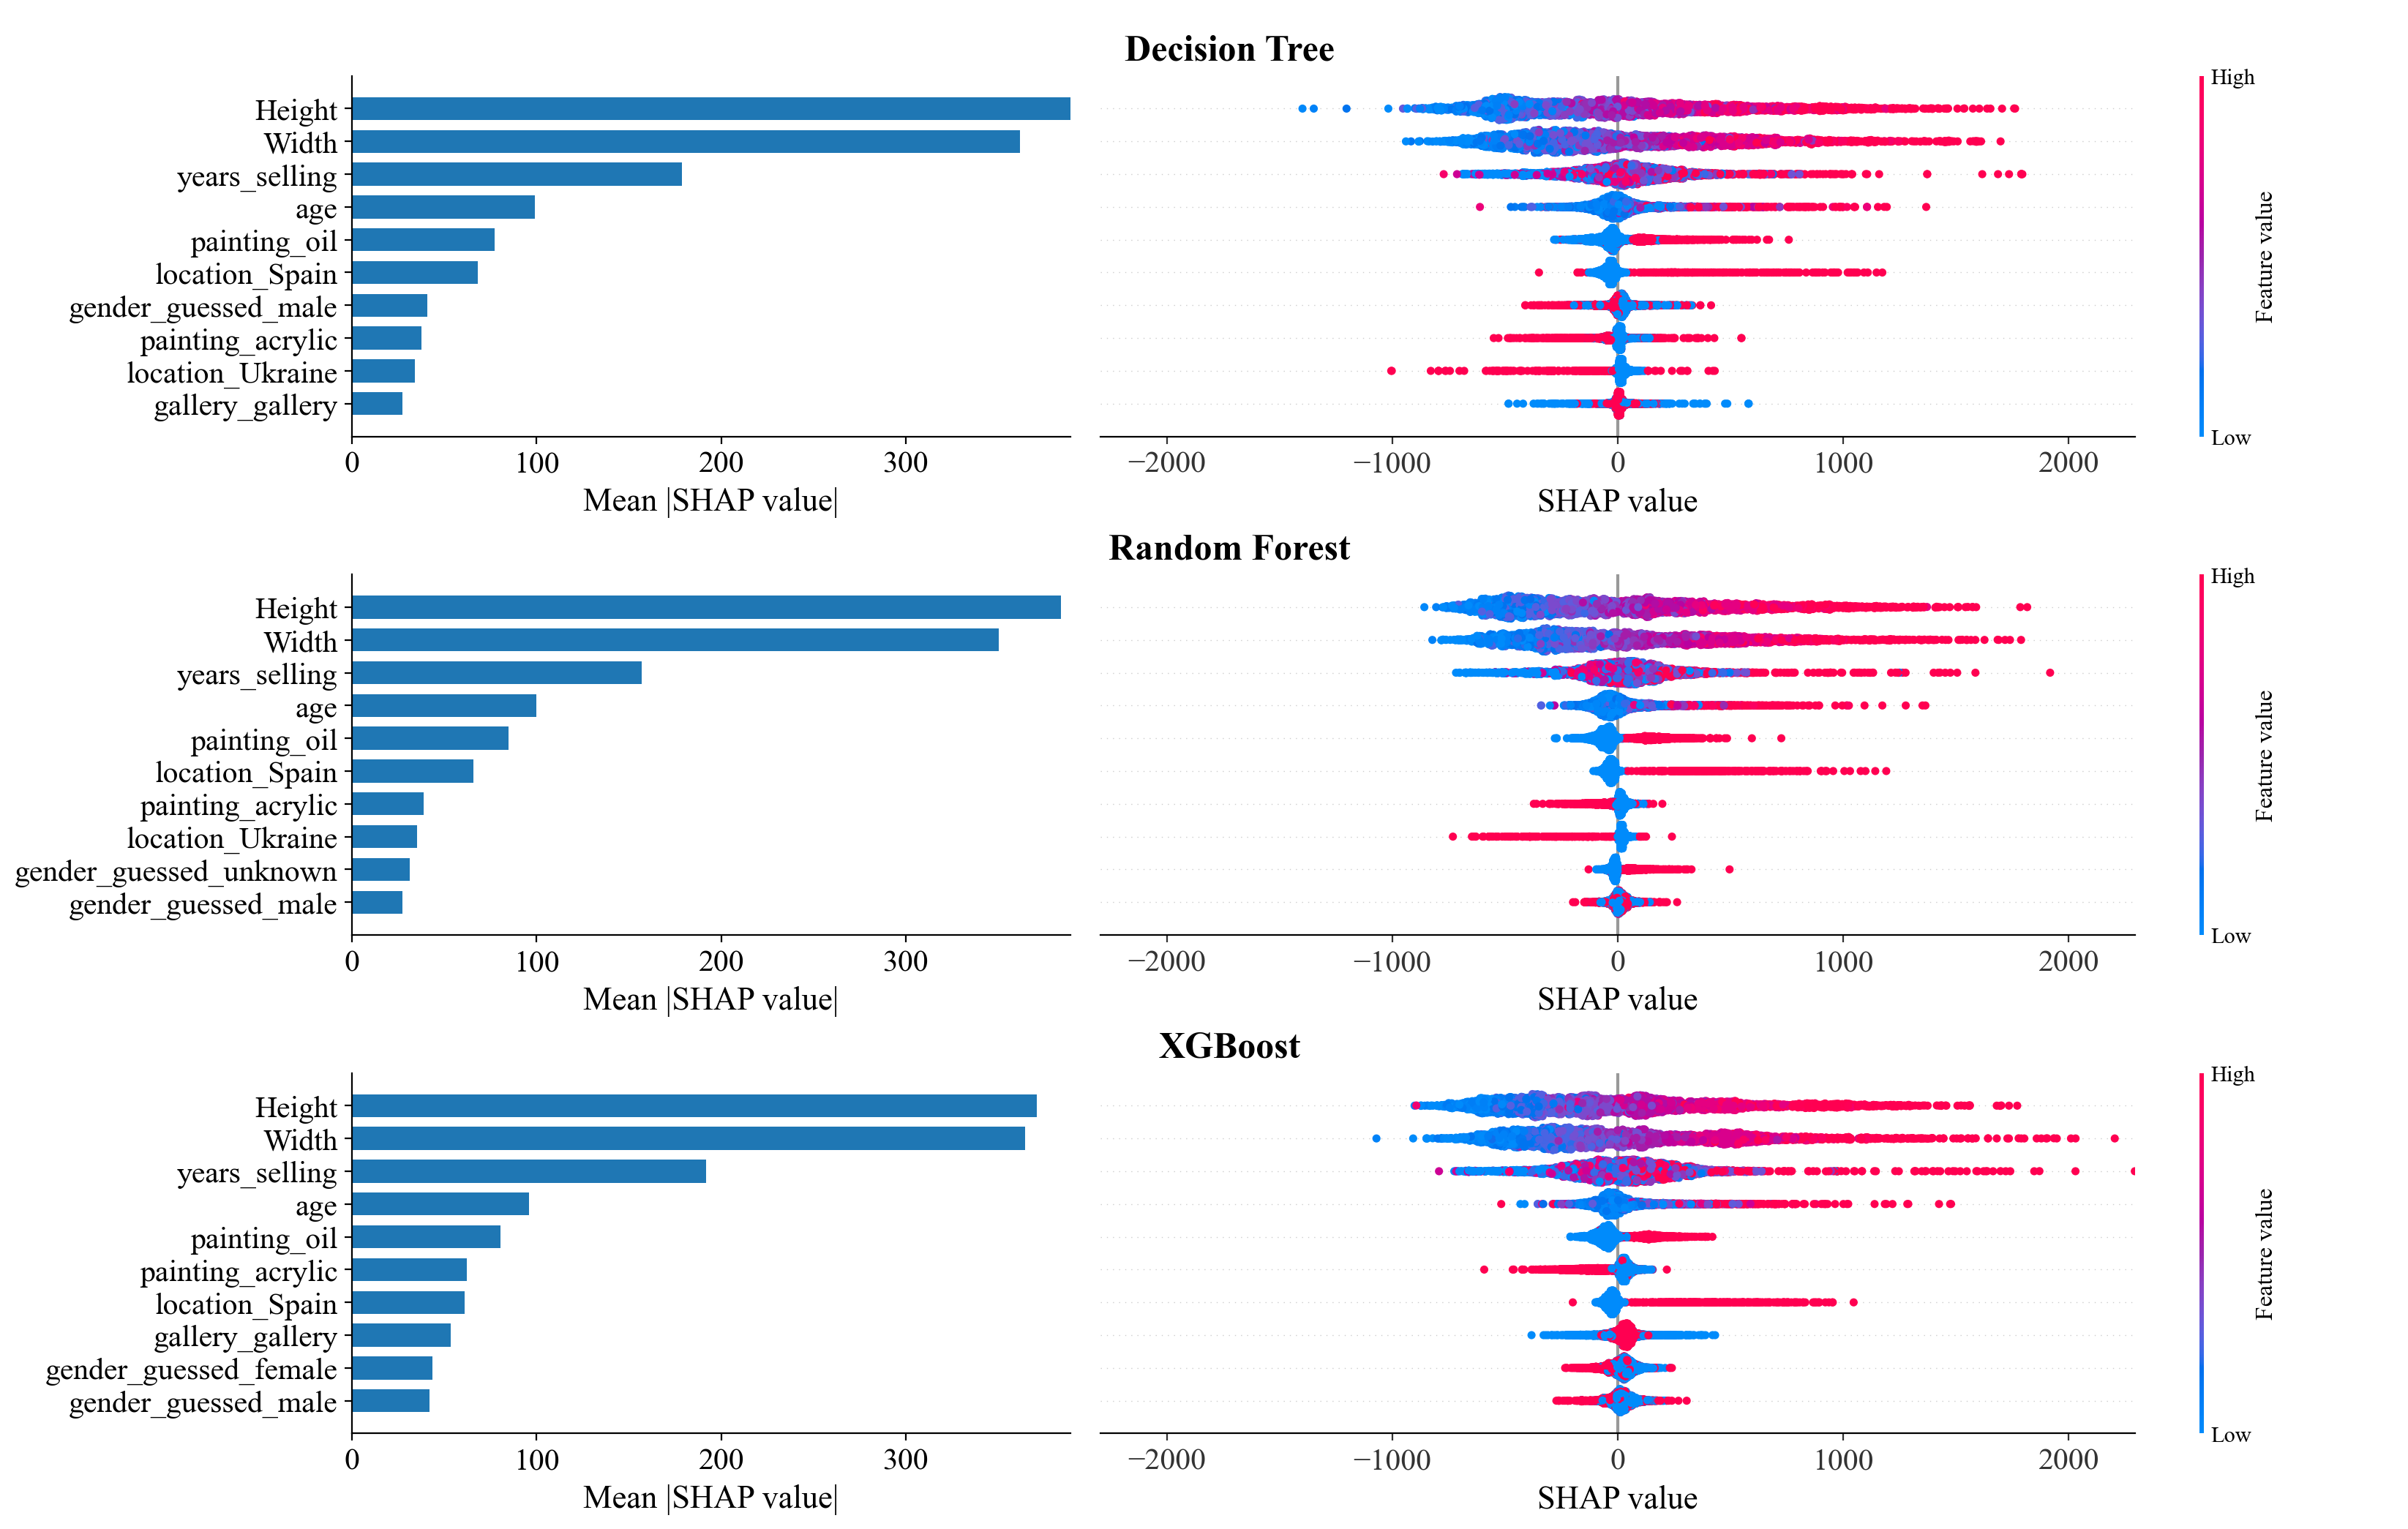

In [13]:



mpl.rcParams["font.family"] = "serif"
mpl.rcParams["font.serif"] = ["Times New Roman"]

TOP_K = 10


TITLE_SIZE = 18
LABEL_SIZE = 16
TICK_SIZE = 15


all_shap_max = []
all_importance_max = []

for res in results_cleaned.values():
    imp = res["importance"].head(TOP_K)
    shap_vals = res["shap_values"][:, imp.index.tolist()]

    all_importance_max.append(imp.values.max())
    all_shap_max.append(np.abs(shap_vals.values).max())

xmax_importance = max(all_importance_max)
xmax_shap = max(all_shap_max)


n_models = len(results_cleaned)

fig = plt.figure(figsize=(18, 4.2 * n_models))

outer = gridspec.GridSpec(
    n_models, 1,
    hspace=0.18,
    figure=fig
)


for i, (name, res) in enumerate(results_cleaned.items()):

    shap_values = res["shap_values"]
    importance = res["importance"].head(TOP_K)


    clean_labels = [
        f.replace("num_", "").replace("cat_", "").lstrip("_")
        for f in importance.index
    ]

    # keep original names for slicing
    top_features = importance.index.tolist()
    shap_values_top = shap_values[:, top_features]


    inner = gridspec.GridSpecFromSubplotSpec(
        2, 2,
        subplot_spec=outer[i],
        height_ratios=[0.16, 1.0],
        width_ratios=[1.0, 1.8],
        hspace=0.02,
        wspace=0.03
    )


    ax_title = fig.add_subplot(inner[0, :])
    ax_title.axis("off")

    ax_title.text(
        0.43, 0.35, name,
        ha="center",
        va="center",
        fontsize=TITLE_SIZE,
        fontweight="bold",
        fontname="Times New Roman",
        transform=ax_title.transAxes
    )


    ax1 = fig.add_subplot(inner[1, 0])

    ax1.barh(
        clean_labels[::-1],   
        importance.values[::-1],
        height=0.7
    )

    ax1.set_xlim(0, xmax_importance)
    ax1.set_xlabel("Mean |SHAP value|", fontsize=LABEL_SIZE)
    ax1.tick_params(axis="both", labelsize=TICK_SIZE)
    ax1.margins(y=0)

    for spine in ["top", "right"]:
        ax1.spines[spine].set_visible(False)

    for label in ax1.get_xticklabels():
        label.set_fontname("Times New Roman")
    for label in ax1.get_yticklabels():
        label.set_fontname("Times New Roman")
    ax1.xaxis.label.set_fontname("Times New Roman")


    ax2 = fig.add_subplot(inner[1, 1])

    shap.plots.beeswarm(
        shap_values_top,
        max_display=TOP_K,
        ax=ax2,
        show=False,
        plot_size=None
    )

    ax2.set_yticklabels([])
    ax2.set_ylabel("")
    ax2.set_xlim(-xmax_shap, xmax_shap)
    ax2.set_xlabel("SHAP value", fontsize=LABEL_SIZE)
    ax2.tick_params(axis="both", labelsize=TICK_SIZE)
    ax2.margins(y=0)

    for label in ax2.get_xticklabels():
        label.set_fontname("Times New Roman")
    for label in ax2.get_yticklabels():
        label.set_fontname("Times New Roman")
    ax2.xaxis.label.set_fontname("Times New Roman")

    ax1.set_ylim(ax2.get_ylim())
    ax2.set_anchor("W")


plt.savefig("shap_comparison_cleaned_tab.png", dpi=300)
plt.show()